In [19]:
import os, sys
from importlib import reload
import pandas as pd
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [33]:
from lucia_stats.src import paths
import lucia_stats.src.data as lucia_data; reload(lucia_data)

df_pandan = lucia_data.get_pandan_csv()
df_noni   = lucia_data.get_noni_csv()
df_mel    = lucia_data.get_mel_csv()
# Keep the rows of df_mel whose InChIKey is not "unsure"
df_mel = df_mel[df_mel['InChIKey'] != 'unsure']

In [34]:
# The InChiKey column in both dataframes codes the odour
# See which odours are in both datasets
common_odours = list(set(df_pandan['InChIKey']).union(df_noni['InChIKey']).intersection(df_mel['InChIKey']))
print(len(common_odours))

44


In [68]:
# Get the odour names for each InChiKey in the common set
def odour_for_inchikey(k):
    """Return the odour name for a given InChiKey from df_mel"""
    # If the key is in pandan use that, otherwise use df_mel
    if k in df_pandan['InChIKey'].values:
        return df_pandan.loc[df_pandan['InChIKey'] == k, 'Odour'].values[0]
    else:
        return df_mel.loc[df_mel['InChIKey'] == k, 'Odour'].values[0]

common_odour_names = {k: odour_for_inchikey(k) for k in common_odours}

In [44]:
def pad_dataframe(df, common_odours,  common_odour_names, padval = 0):
    """Pad the dataframe with rows for each odour in common_odours that is not already in df"""
    out = df.set_index('InChIKey').reindex(common_odours)
    out['Odour'] = out.index.map(common_odour_names)
    sample_cols = out.columns.difference(['Odour'])
    out[sample_cols] = out[sample_cols].fillna(padval)
    return out.reset_index()

In [69]:
df_pandan_common = pad_dataframe(df_pandan, common_odours, common_odour_names).drop(columns='Odour')
df_noni_common = pad_dataframe(df_noni, common_odours, common_odour_names).drop(columns='Odour')
df_mel_common = (
    df_mel[df_mel['InChIKey'].isin(common_odours)]
    .drop(columns='Odour')
    .groupby('InChIKey', sort=False)
    .sum()
    .reindex(common_odours)
    .reset_index()
)

In [70]:
# The data frames have odours on each row, and samples on each column.
# Transpose the data frames so that samples are on each row, and odours on each column.
df_pandan_common_T = df_pandan_common.set_index('InChIKey').T
df_noni_common_T   = df_noni_common.set_index('InChIKey').T
df_mel_common_T    = df_mel_common.set_index('InChIKey').T
# Add a column to each dataframe indicating the dataset (pandan, noni, or mel)
df_pandan_common_T['dataset'] = 'pandan'
df_noni_common_T['dataset'] = 'noni'
df_mel_common_T['dataset'] = 'mel'

# Add a column saying which sample it was (e.g. B_rep1 -> B)
df_pandan_common_T['sample'] = df_pandan_common_T.index.str.split('_').str[0]
df_noni_common_T['sample'] = df_noni_common_T.index.str.split('_').str[0]
# Mel just has one sample, so just use whatever the column name is
df_mel_common_T['sample'] = df_mel_common_T.index

# Add a column saying which replicate it was (e.g. B_rep1 -> 1)
df_pandan_common_T['replicate'] = df_pandan_common_T.index.str.split('_').str[1].str.replace('rep', '').astype(int)
df_noni_common_T['replicate'] = df_noni_common_T.index.str.split('_').str[1].str.replace('rep', '').astype(int)
df_mel_common_T['replicate'] = 1  # Mel just has one replicate, so just use 1

# Let the multi-index be (dataset, sample, replicate)
df_pandan_common_T = df_pandan_common_T.set_index(['dataset', 'sample', 'replicate'])
df_noni_common_T = df_noni_common_T.set_index(['dataset', 'sample', 'replicate'])
df_mel_common_T = df_mel_common_T.set_index(['dataset', 'sample', 'replicate'])

In [71]:
# Concatenate the three dataframes
df_combined = pd.concat([df_pandan_common_T, df_noni_common_T, df_mel_common_T])
# Drop any rows whose values are all 0 
df_combined = df_combined.loc[~(df_combined == 0).all(axis=1)]

# Classification

In [87]:
col_odours = [common_odour_names[k] for k in df_combined.columns]
def plot_heatmap(Z, column_labs, cmap = 'RdYlBu_r', vmin = -3, vmax = 3, figsize = (18,4), ax = None):
    if ax is None:
        figure(figsize=figsize)
        ax = gca()
    im = ax.matshow(Z.T, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.axis("auto")
    # Set the y ticks to be the odour names
    ax.set_yticks(range(len(col_odours)))
    ax.set_yticklabels(col_odours, fontsize=12)
    ax.set_xticks(range(len(column_labs)))
    ax.set_xticklabels(column_labs, rotation=90, fontsize=12)
    # Add a colorbar
    cbar = colorbar(im, ax=ax)

def plot_rf_importances(importances, held_out, scores):
    figure(figsize=(18,10))
    ax = subplot(4,1,(1,3))
    plot_heatmap(importances.values, ax = ax, column_labs = held_out, cmap = 'Spectral_r', vmin = 0, vmax = 0.4, figsize = (18,4))
    ax.set_title(f"Random Forest Feature (Odour) Importances (colours) and Accuracy (gray) ", fontsize=16)
    ax2 = subplot(4,1,4, sharex=ax)
    # Make a bar graph, with one bar for each held out sample, showing the accuracy of the model when that sample was held out
    # Align the bars with the heatmap above
    bar(range(len(held_out)), scores, color='gray', alpha=0.7)
    ax2.set_xticks(range(len(held_out)))
    ax2.set_xticklabels(held_out, rotation=90, fontsize=12)
    # Set the position of ax2 so that it is below ax, and has the same width as ax
    pos, pos2 = ax.get_position(), ax2.get_position()
    ax2.set_position([pos.x0, pos2.y0, pos.width, pos2.height])
    ax2.set_ylim(0, 1.05)
    ax2.set_ylabel("Accuracy", fontsize=15)
    ax2.set_xlabel("Held Out Sample", fontsize=15)
    return ax, ax2

In [77]:
# Import zscore
from scipy.stats import zscore
# Extract the values as X, the dataset as y, and the sample as groups
X = df_combined.values
# Z score the rows
Z = zscore(X, axis=1)
groups = np.array([f"{ds}_{samp}" for ds, samp in zip(df_combined.index.get_level_values('dataset'), df_combined.index.get_level_values('sample'))])

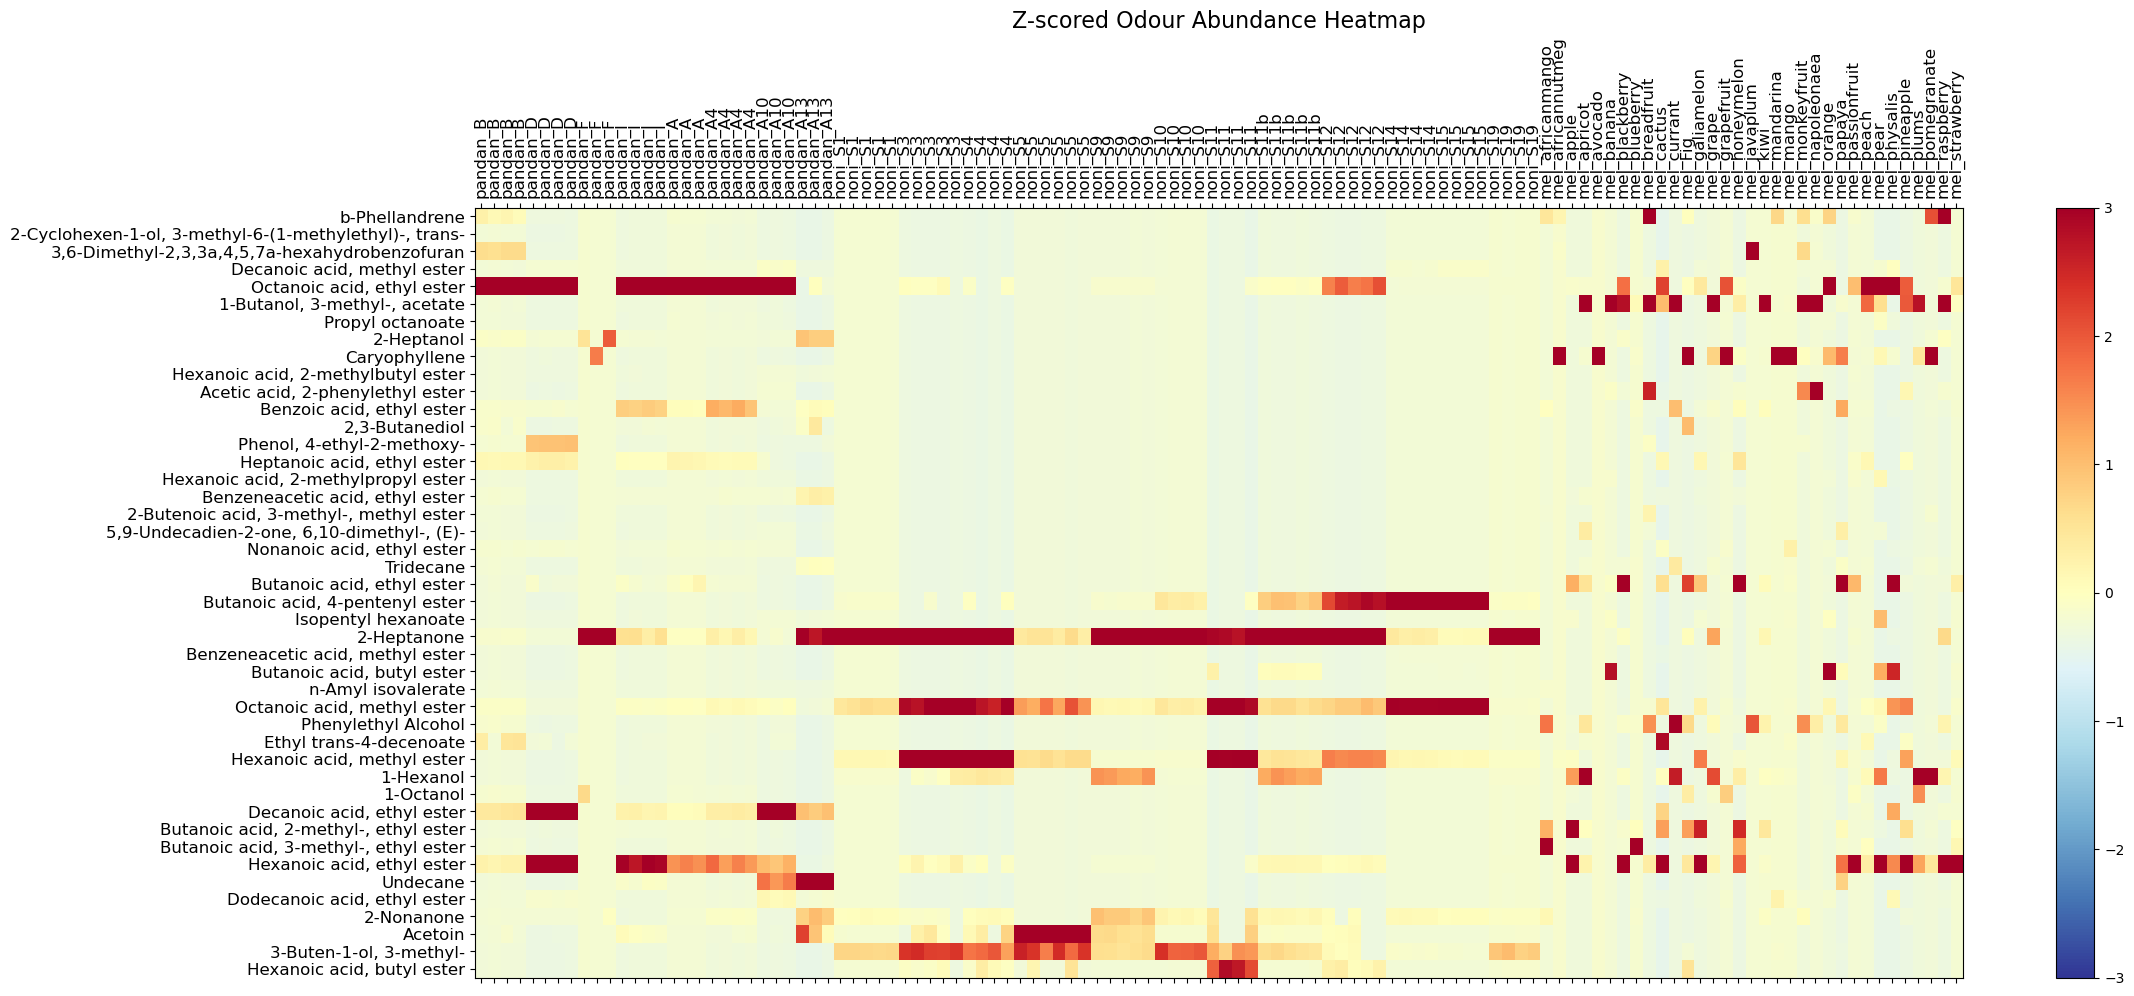

In [83]:
plot_heatmap(Z, column_labs=groups, cmap = 'RdYlBu_r', vmin = -3, vmax = 3, figsize = (24,10))
title("Z-scored Odour Abundance Heatmap", fontsize=16)
savefig(os.path.join(paths.figs_path, "odours-heatmap.pdf"), dpi=600, bbox_inches='tight')

In [96]:
from sklearn.model_selection import LeaveOneGroupOut, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier

In [114]:
class_weight = None # Use balanced class weights to handle class imbalance
logo = LeaveOneGroupOut()
def run_random_forest(X, y, groups, n_estimators=1000, random_state=42):
    cv_out = cross_validate(
        RandomForestClassifier(random_state=random_state, 
                               class_weight = class_weight),
        X, y,
        cv=logo,
        groups=groups,
        return_estimator=True,
        )

    scores=cv_out["test_score"]

    held_out = [groups[test][0] for _, test in logo.split(X, y, groups)]
    importances = pd.DataFrame(
        [est.feature_importances_ for est in cv_out["estimator"]],
        index=pd.Index(held_out, name="held_out"),
        columns = df_combined.columns
    )
    return importances, held_out, scores

Saved figure to /Users/sinatootoonian/git/lucia-natural-odour-stats/lucia_stats/figs/pandan_vs_others.pdf


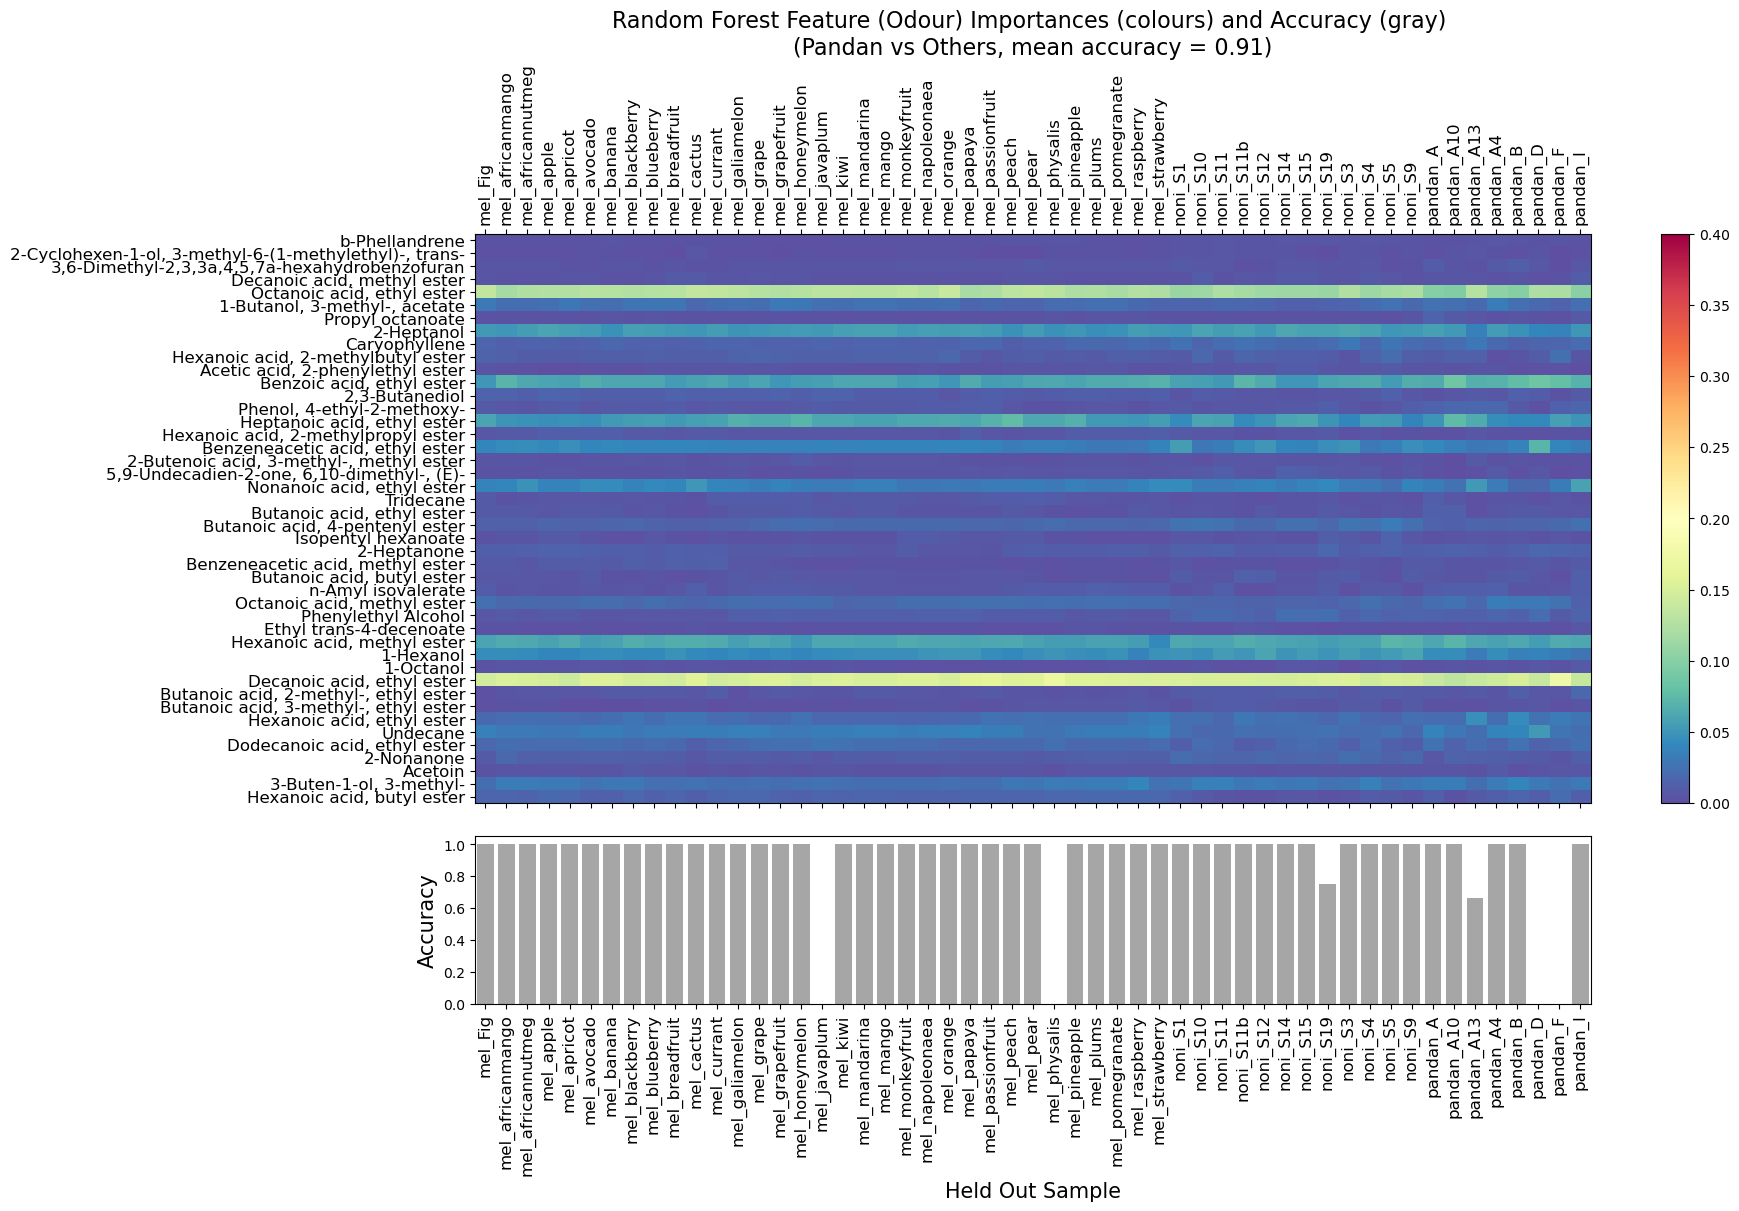

In [128]:
# Make a RF classifier to classify Pandan vs The others
which_fruit = "pandan"
y = [lab == which_fruit for lab in df_combined.index.get_level_values('dataset')]
y_pred = cross_val_predict(RandomForestClassifier(random_state=42, class_weight=class_weight), Z, y, cv=logo, groups=groups)
importances, held_out, scores = run_random_forest(Z, y, groups)
ax, ax2 = plot_rf_importances(importances, held_out, scores)
ttl = ax.get_title()
ttl = ttl + f"\n({which_fruit.capitalize()} vs Others, mean accuracy = {np.mean(scores):.2f})"
ax.set_title(ttl, fontsize =16)
fig_name = os.path.join(paths.figs_path, f"{which_fruit}_vs_others.pdf")
savefig(fig_name, dpi=600, bbox_inches='tight')
print(f"Saved figure to {fig_name}")

In [129]:
out_dir = "~/temp"
#  Make a CSV of the importances per held out odour, 
importances_and_scores = importances.copy()
importances_and_scores['accuracy'] = scores
importances_and_scores.to_csv(os.path.join(out_dir, f"{which_fruit}_vs_others_importances_and_accuracy.csv"))

In [126]:
# Create a CSV mapping each InChiKey to its odour name
inchi_odour_mapping = pd.DataFrame.from_dict(common_odour_names, orient='index', columns=['Odour'])
inchi_odour_mapping.index.name = 'InChiKey'
inchi_odour_mapping.to_csv(os.path.join(out_dir, "inchi_odour_mapping.csv"))